Real-Time Credit Risk Simulation

Lightweight, real-time credit risk analysis pipeline that simulates event ingestion, processes streaming data in pandas, applies logistic regression for prediction, and generates actionable business recommendations.

Sets up the environment and imports `run_pipeline()`.

Checks if the output parquet file exists and deletes it to ensure a fresh pipeline run.

Prints a message to indicate whether the file was removed or not.


In [1]:
import sys
import pandas as pd
import threading
import time
import matplotlib.pyplot as plt

# -----------------------------
# Add project root to sys.path for module imports
# -----------------------------
root = "/Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation"
sys.path.append(root)

# -----------------------------
# Import external python modules
# -----------------------------

from pathlib import Path
from src.pipeline import run_pipeline
from src.viz.plots import Plots

# -----------------------------
# Display full dataframes
# -----------------------------

pd.set_option('display.max_rows', None) # reset_option to compact dataframe view
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

# -----------------------------
# Define path to processed parquet file
# -----------------------------
file_path = Path(
    '/Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation/src/data/processed/processed_df.parquet'
)

# -----------------------------
# Delete existing parquet file for a fresh execution
# -----------------------------
if file_path.exists():
    file_path.unlink()
    print(f"Deleted existing file: {file_path}", flush=True)
else:
    print("No existing parquet file found. Continuing...", flush=True)

Deleted existing file: /Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation/src/data/processed/processed_df.parquet


Runs `run_pipeline()` in a separate thread so the notebook can monitor progress in real time.

Continuously reads the output parquet file and prints changes to the DataFrame whenever new events are added.

After the pipeline finishes, its size and graphs of the final DataFrame are displayed 

Monitoring parquet file for updates...

Event producing has initiated.
Event consuming has initiated.

Processing is complete.

Final DataFrame shape: (36420, 8)



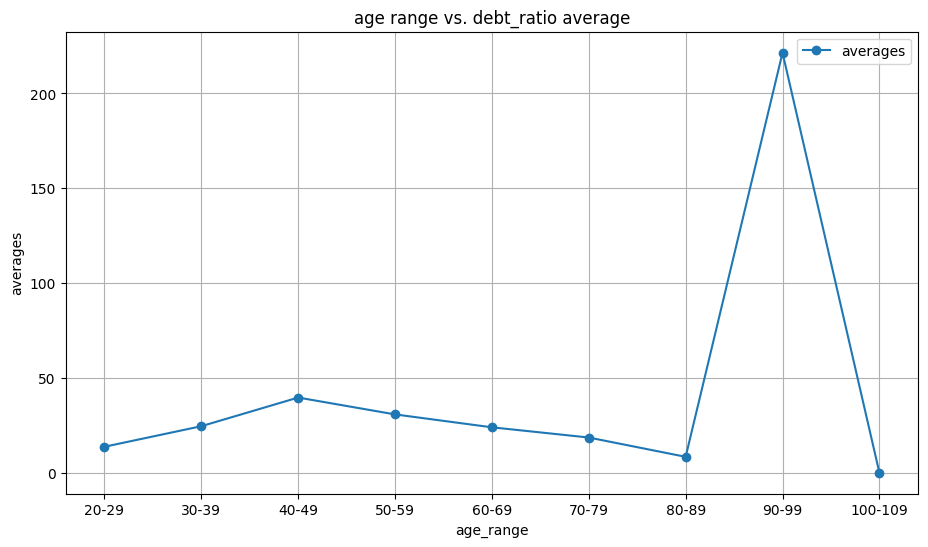

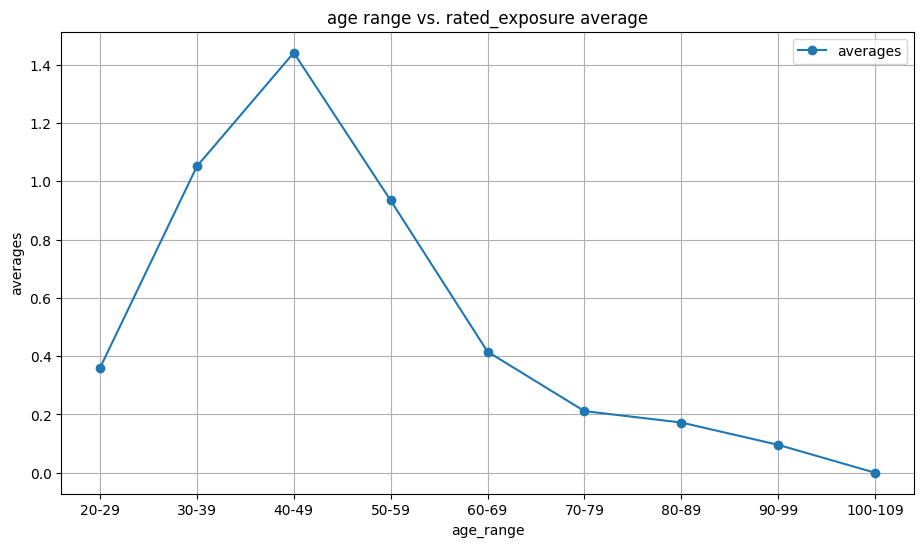

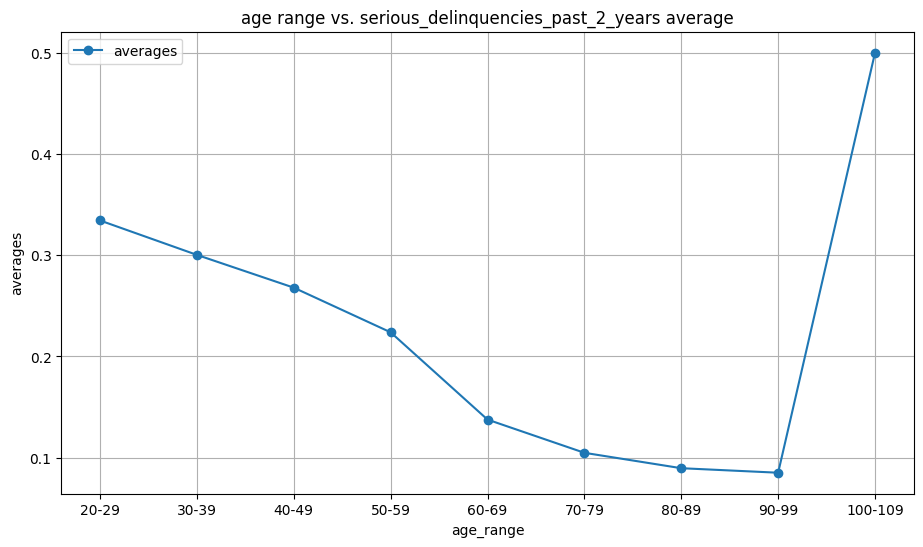

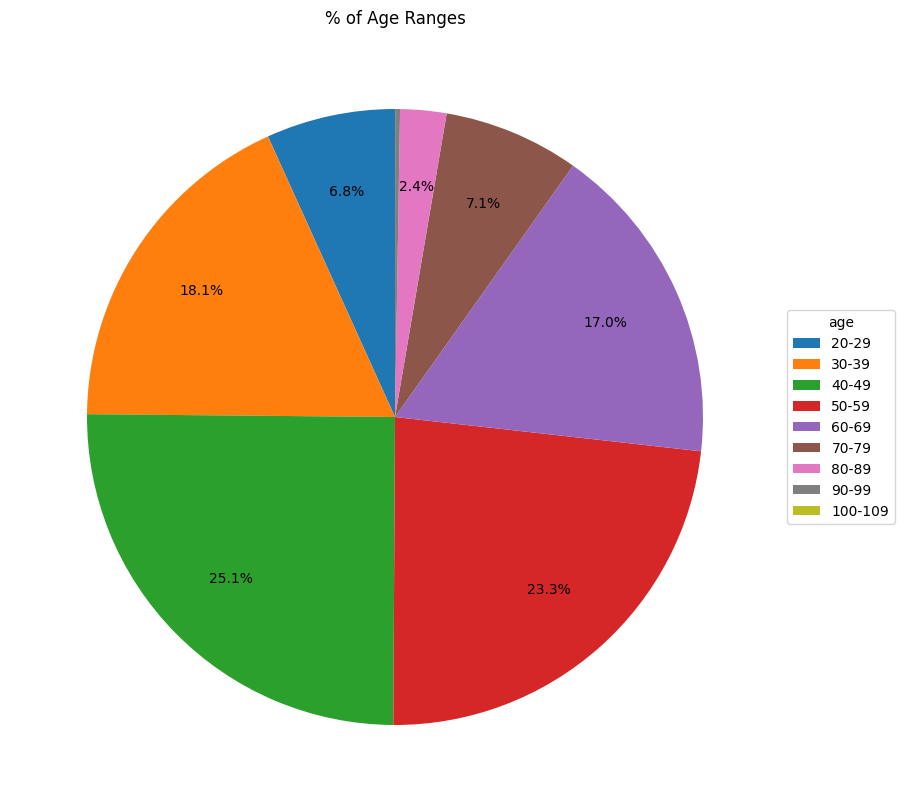

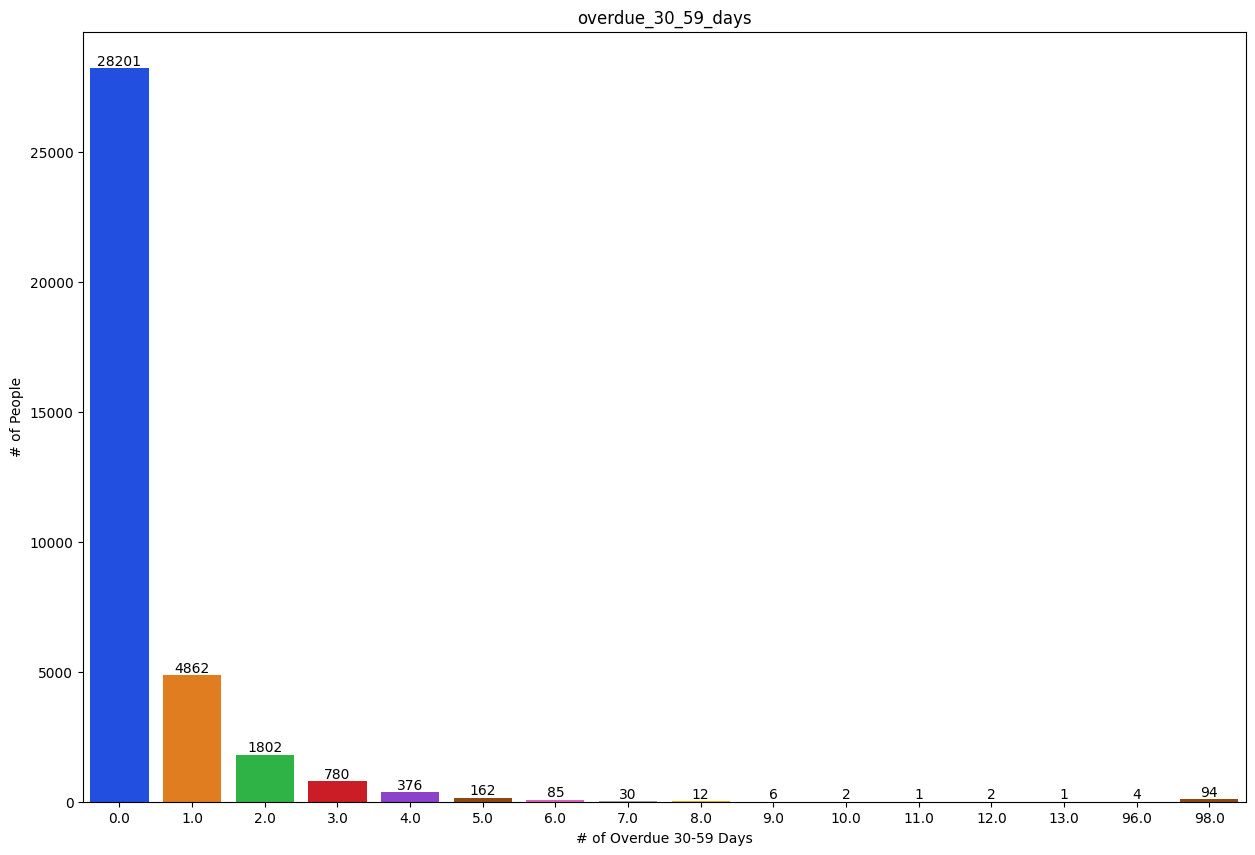

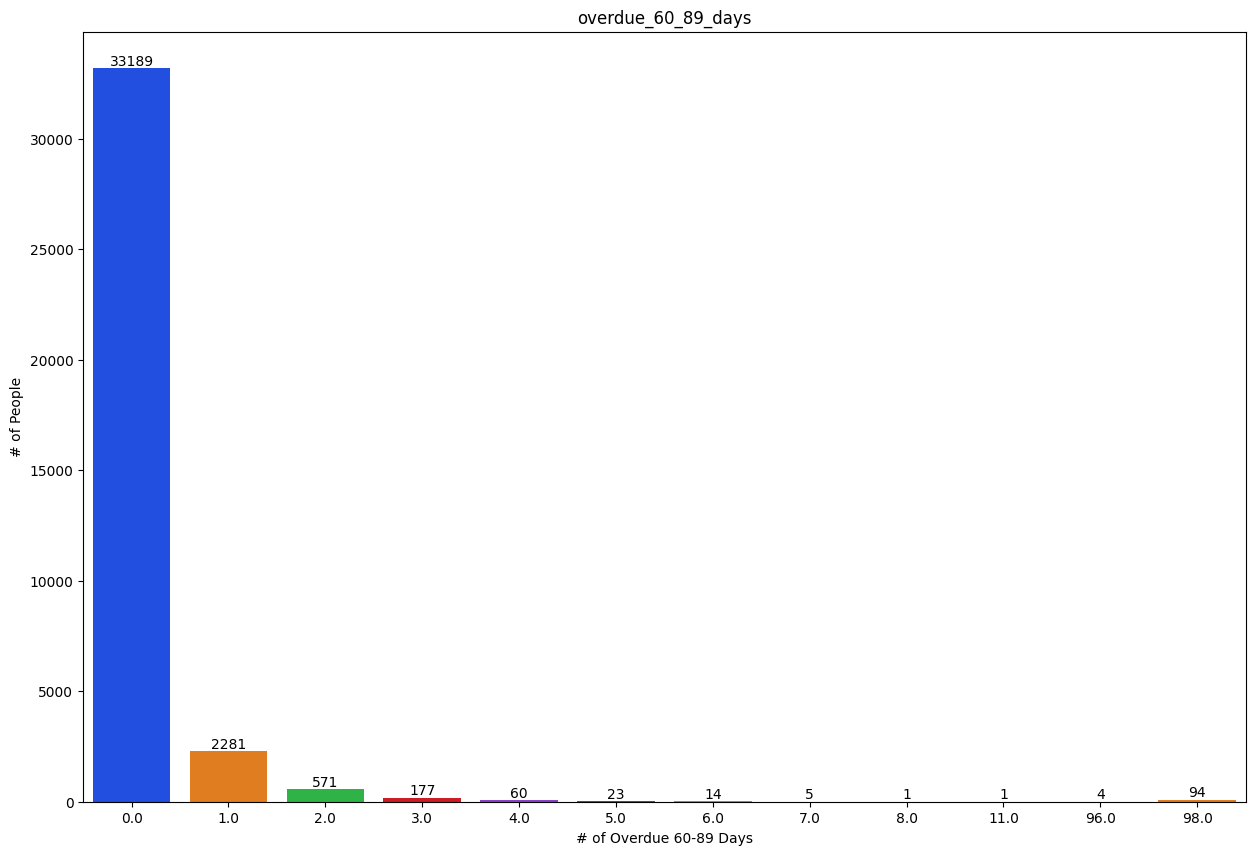

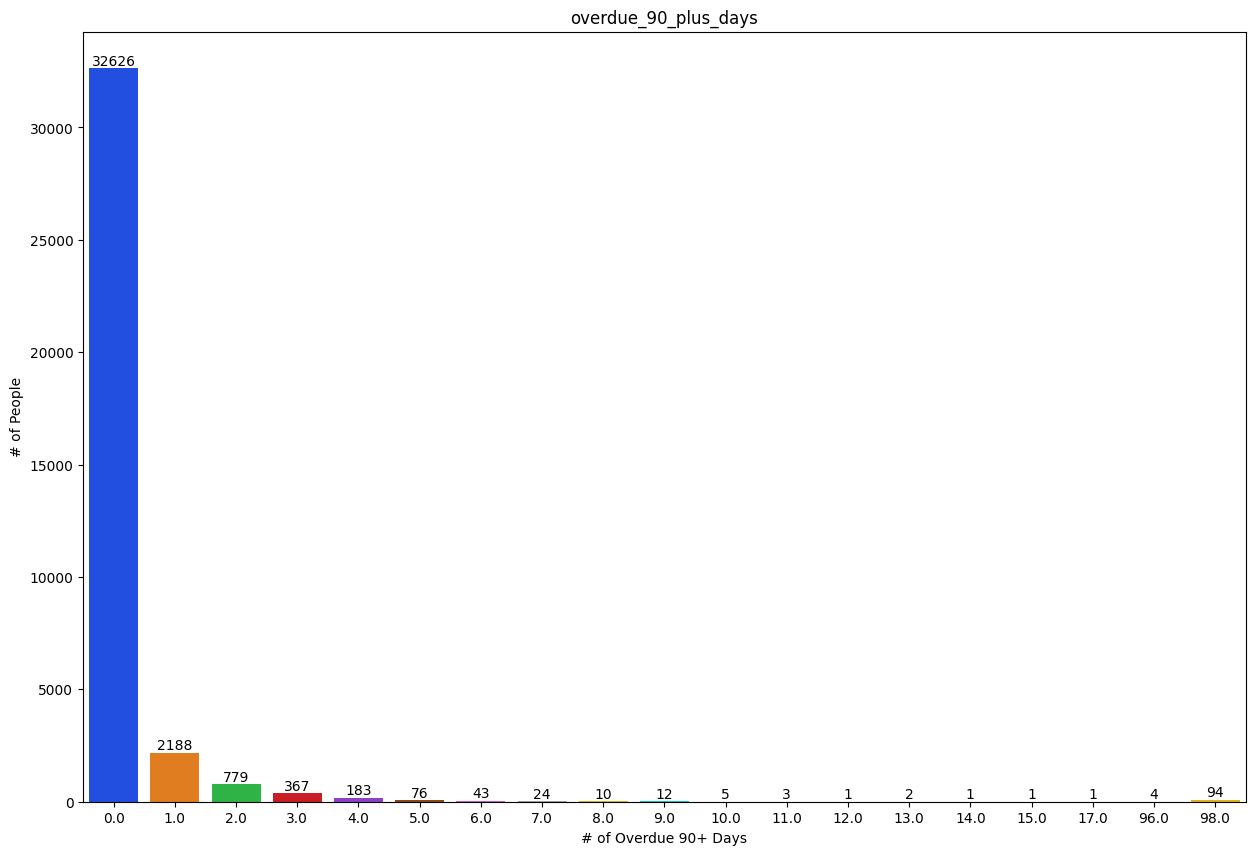

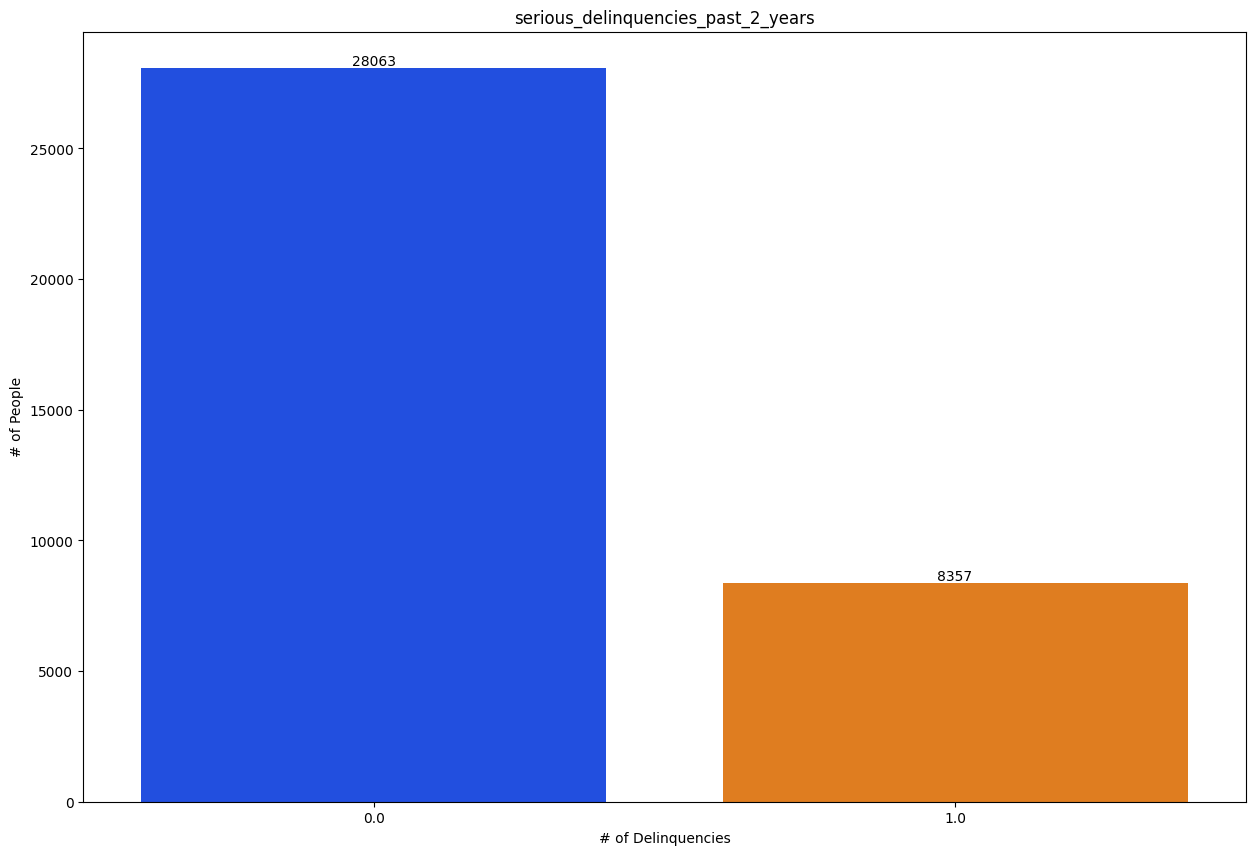

In [2]:
# -----------------------------
# Initialize variables
# -----------------------------
previous_shape = (0, 0)
current_df = pd.DataFrame(columns=[])

# -----------------------------
# Start pipeline in a separate thread
# -----------------------------
pipeline_thread = threading.Thread(target=run_pipeline, daemon=True)
pipeline_thread.start()
print("Monitoring parquet file for updates...\n")

# -----------------------------
# Real-time monitoring loop
# -----------------------------
while pipeline_thread.is_alive():
    if file_path.exists():
        try:
            df = pd.read_parquet(file_path, engine='fastparquet')
            if not df.empty and df.shape != previous_shape:
                previous_shape = df.shape
        except Exception:
            pass
    time.sleep(0.05)

# -----------------------------
# Wait for pipeline thread to finish
# -----------------------------
pipeline_thread.join()

# -----------------------------
# Graph final DataFrame results
# -----------------------------
if file_path.exists():
    df = pd.read_parquet(file_path, engine='fastparquet')
    print(f"Final DataFrame shape: {df.shape}\n")

    """Line Graphs"""
    Plots.plot_age_range_comparison_avg(df, df.columns[0], df.columns[2]) # debt ratio
    Plots.plot_age_range_comparison_avg(df, df.columns[0], df.columns[3]) # rated exposure
    Plots.plot_age_range_comparison_avg(df, df.columns[0], df.columns[7]) # serious delinquencies

    """Pie Graphs"""
    Plots.plot_age_ranges(df, df.columns[0], title='% of Age Ranges')

    """Bar Graphs"""
    Plots.plot_days_overdue_counts(df, df.columns[4], x_label='# of Overdue 30-59 Days', y_label='# of People')
    Plots.plot_days_overdue_counts(df, df.columns[5], x_label='# of Overdue 60-89 Days', y_label='# of People')
    Plots.plot_days_overdue_counts(df, df.columns[6], x_label='# of Overdue 90+ Days', y_label='# of People')
    Plots.plot_days_overdue_counts(df, df.columns[7], x_label='# of Delinquencies', y_label='# of People')

    plt.show()

else:
    print("Pipeline finished but file was not found.")

Exploratory data analysis (EDA) is performed on the final DataFrame to visualize key metrics and trends.

In [3]:
# -----------------------------
# Statistics of final DataFrame
# -----------------------------
df.describe()

,age,monthly_revenue,debt_ratio,rated_exposure,overdue_30_59_days,overdue_60_89_days,overdue_90_plus_days,serious_delinquencies_past_2_years
count,36420.000000,36420.000000,36420.000000,36420.000000,36420.000000,36420.000000,36420.000000,36420.000000
mean,50.298270,6452.263399,28.624407,0.883608,0.649478,0.385585,0.448545,0.229462
std,14.267377,12638.167723,446.594563,1.160570,5.134173,5.088125,5.113121,0.420493
min,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,3286.000000,0.145980,0.000000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,5166.000000,0.304183,0.000000,0.000000,0.000000,0.000000,0.000000
75%,60.000000,8000.000000,0.501672,2.000000,0.000000,0.000000,0.000000,0.000000
max,103.000000,1794060.000000,49112.000000,10.000000,98.000000,98.000000,98.000000,1.000000
